# Notebook 02: Model Training and Scenario Simulation
## Hormuz Shock Propagation Model

This notebook does two things. First, it trains a LightGBM model to predict
daily Brent Crude log returns using conflict event features alongside standard
price lags. Second, it runs a Monte Carlo simulation to produce 30-day price
distributions under three war scenarios: ceasefire, frozen conflict, and full
escalation.

The panel built in notebook 01 feeds directly into this one.  

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
import lightgbm as lgb

plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#1a1d27",
    "axes.edgecolor":   "#333344",
    "axes.labelcolor":  "#aaaaaa",
    "text.color":       "#cccccc",
    "xtick.color":      "#aaaaaa",
    "ytick.color":      "#aaaaaa",
    "grid.color":       "#2a2d3a",
    "grid.linestyle":   "--",
    "grid.alpha":       0.5,
    "font.family":      "monospace",
})


In [3]:
panel = pd.read_csv("../data/processed/daily_panel.csv", index_col="date", parse_dates=True)

print(f"Panel shape    : {panel.shape}")
print(f"Date range     : {panel.index.min().date()} to {panel.index.max().date()}")
print(f"War-period rows: {panel['war_period'].sum()}")
panel.tail(3)

Panel shape    : (576, 25)
Date range     : 2024-01-03 to 2026-04-17
War-period rows: 34


,open,high,low,close,volume,daily_return,escalation_score,de_escalation_score,hormuz_threat,n_events,...,ma_20,volatility_10d,return_lag_1,close_lag_1,return_lag_2,close_lag_2,return_lag_3,close_lag_3,return_lag_5,close_lag_5
date,,,,,,,,,,,,,,,,,,,,,
2026-04-15,95.519997,96.889999,91.000000,94.930000,41928,0.001476,0.0,0.0,0.0,0.0,...,104.5380,0.074560,-0.047086,94.790001,0.042770,99.360001,-0.007535,95.199997,-0.142580,94.750000
2026-04-16,94.910004,99.839996,94.419998,99.389999,36540,0.045912,0.0,0.0,0.0,0.0,...,104.1385,0.059946,0.001476,94.930000,-0.047086,94.790001,0.042770,99.360001,0.012273,95.919998
2026-04-17,98.250000,98.970001,86.080002,90.379997,82451,-0.095029,0.0,4.0,0.0,1.0,...,103.2250,0.059880,0.045912,99.389999,0.001476,94.930000,-0.047086,94.790001,-0.007535,95.199997


## Feature Matrix

We use 16 features split into two groups. Price and momentum features
(lagged returns, moving averages, rolling volatility) form the backbone
because short-term oil returns are strongly autocorrelated. Conflict
features (escalation scores, Hormuz flags, war period) sit on top of
that and are expected to contribute most to volatility and tail risk
rather than day-to-day direction.

In [5]:
FEATURES = [
    "return_lag_1", "return_lag_2", "return_lag_3", "return_lag_5",
    "close_lag_1", "close_lag_2",
    "volatility_10d",
    "escalation_score", "de_escalation_score",
    "net_conflict_7d",
    "hormuz_threat", "hormuz_closed",
    "war_period",
    "n_events",
    "ma_5", "ma_20",
]
TARGET = "daily_return"

df_model = panel[FEATURES + [TARGET, "close"]].dropna()
X = df_model[FEATURES].values
y = df_model[TARGET].values

print(f"Training rows : {len(df_model)}")
print(f"Features      : {len(FEATURES)}")
print(f"\nFeature list:")
for f in FEATURES:
    print(f"  {f}")

Training rows : 558
Features      : 16

Feature list:
  return_lag_1
  return_lag_2
  return_lag_3
  return_lag_5
  close_lag_1
  close_lag_2
  volatility_10d
  escalation_score
  de_escalation_score
  net_conflict_7d
  hormuz_threat
  hormuz_closed
  war_period
  n_events
  ma_5
  ma_20


## Time-Series Cross-Validation

We use 5-fold time-series split so the model is always trained on the
past and validated on the future. No data leakage. The last fold covers
the war period, which is why we expect its error to be higher - the
model has not seen that regime during training.

In [6]:
lgb_params = {
    "objective":        "regression",
    "n_estimators":     300,
    "learning_rate":    0.03,
    "max_depth":        4,
    "num_leaves":       15,
    "min_child_samples": 10,
    "subsample":        0.8,
    "colsample_bytree": 0.8,
    "reg_alpha":        0.1,
    "reg_lambda":       0.1,
    "verbose":          -1,
    "random_state":     42,
}

tscv = TimeSeriesSplit(n_splits=5)
cv_maes, cv_rmses = [], []

print("Fold   MAE        RMSE")
print("-" * 30)
for fold, (train_idx, val_idx) in enumerate(tscv.split(X), 1):
    X_tr, X_val = X[train_idx], X[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    m = lgb.LGBMRegressor(**lgb_params)
    m.fit(X_tr, y_tr,
          eval_set=[(X_val, y_val)],
          callbacks=[lgb.early_stopping(30, verbose=False),
                     lgb.log_evaluation(period=-1)])

    preds = m.predict(X_val)
    mae  = mean_absolute_error(y_val, preds)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    cv_maes.append(mae)
    cv_rmses.append(rmse)
    print(f"  {fold}    {mae*100:.4f}%   {rmse*100:.4f}%")

print("-" * 30)
print(f"  Mean  {np.mean(cv_maes)*100:.4f}%   {np.mean(cv_rmses)*100:.4f}%")

Fold   MAE        RMSE
------------------------------
  1    1.4904%   1.9175%
  2    1.1825%   1.5487%
  3    1.5306%   2.1460%
  4    1.2322%   1.5643%
  5    2.8060%   4.1732%
------------------------------
  Mean  1.6483%   2.2699%


In [7]:
final_model = lgb.LGBMRegressor(**lgb_params)
final_model.fit(X, y, callbacks=[lgb.log_evaluation(period=-1)])
in_sample_preds = final_model.predict(X)
residuals = y - in_sample_preds

importance_df = pd.DataFrame({
    "feature":    FEATURES,
    "importance": final_model.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("Feature importance (top 10):")
print(importance_df.head(10).to_string(index=False))

Feature importance (top 10):
        feature  importance
 volatility_10d         511
   return_lag_2         392
   return_lag_5         290
   return_lag_3         279
   return_lag_1         249
    close_lag_1         197
          ma_20         178
           ma_5         169
    close_lag_2         154
net_conflict_7d          67


## Model Diagnostics

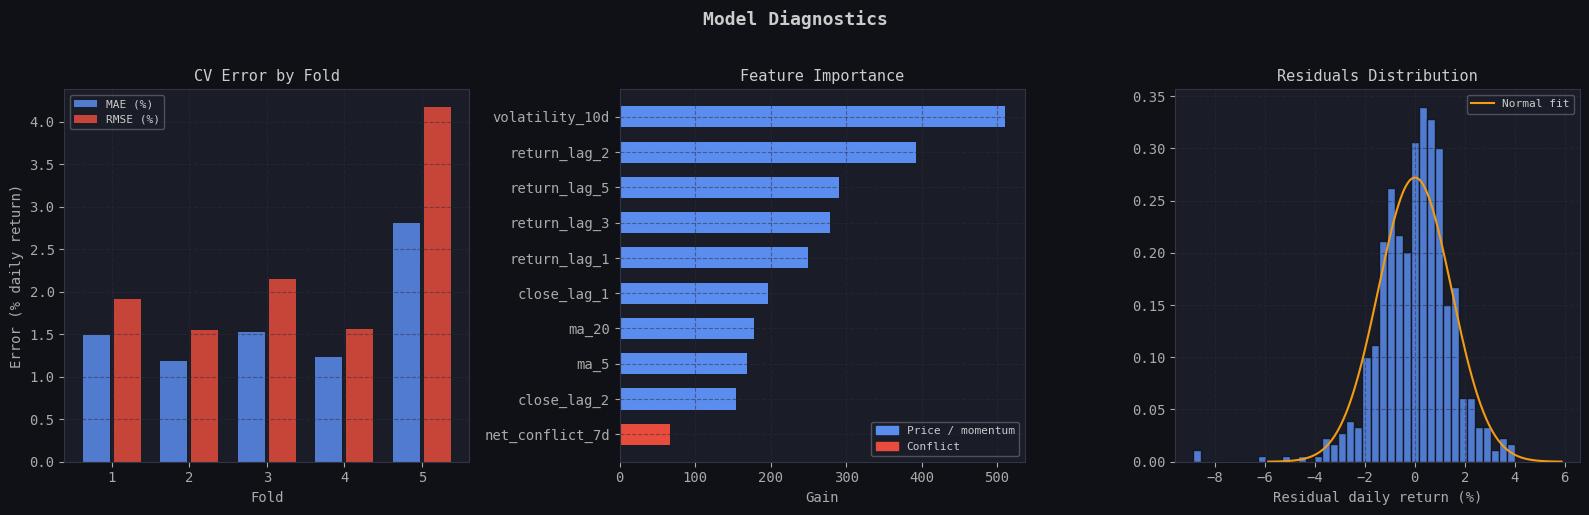

Residual std : 1.4666%
Residual mean: 0.0055%


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# CV performance by fold
ax = axes[0]
folds = range(1, 6)
ax.bar([f - 0.2 for f in folds], [m * 100 for m in cv_maes],
       width=0.35, color="#5b8dee", label="MAE (%)", alpha=0.85)
ax.bar([f + 0.2 for f in folds], [r * 100 for r in cv_rmses],
       width=0.35, color="#e74c3c", label="RMSE (%)", alpha=0.85)
ax.set_title("CV Error by Fold", fontsize=11)
ax.set_xlabel("Fold")
ax.set_ylabel("Error (% daily return)")
ax.legend(fontsize=8, framealpha=0.3)
ax.grid(True)

# Feature importance
ax = axes[1]
top10 = importance_df.head(10)
colors = ["#e74c3c" if any(k in f for k in ["hormuz", "escalat", "conflict", "war", "n_events"])
          else "#5b8dee"
          for f in top10["feature"]]
ax.barh(top10["feature"], top10["importance"], color=colors, height=0.6)
ax.invert_yaxis()
ax.set_title("Feature Importance", fontsize=11)
ax.set_xlabel("Gain")
blue_p  = mpatches.Patch(color="#5b8dee", label="Price / momentum")
red_p   = mpatches.Patch(color="#e74c3c", label="Conflict")
ax.legend(handles=[blue_p, red_p], fontsize=8, framealpha=0.3)
ax.grid(True)

# Residuals distribution
ax = axes[2]
ax.hist(residuals * 100, bins=40, color="#5b8dee",
        edgecolor="#0f1117", alpha=0.85, density=True)
mu    = residuals.mean() * 100
sigma = residuals.std() * 100
x_range = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
normal  = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_range - mu) / sigma)**2)
ax.plot(x_range, normal, color="#f39c12", linewidth=1.5, label="Normal fit")
ax.set_title("Residuals Distribution", fontsize=11)
ax.set_xlabel("Residual daily return (%)")
ax.legend(fontsize=8, framealpha=0.3)
ax.grid(True)

fig.suptitle("Model Diagnostics", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../outputs/02_model_diagnostics.png", dpi=150,
            bbox_inches="tight", facecolor="#0f1117")
plt.show()

print(f"Residual std : {sigma:.4f}%")
print(f"Residual mean: {mu:.4f}%")

## Scenario Simulation

We run 5,000 Monte Carlo paths over a 30-day horizon under three scenarios.
Each scenario sets a fixed conflict feature state. The model predicts an
expected return for each step, and we add noise drawn from the in-sample
residual distribution to get the full range of outcomes.

The three scenarios reflect the realistic range of where this conflict goes
over the next month, based on current reporting as of April 2026.

In [9]:
SCENARIOS = {
    "Ceasefire": {
        "escalation_score":    0,
        "de_escalation_score": 4,
        "hormuz_threat":       0,
        "hormuz_closed":       0,
        "war_period":          1,
        "n_events":            1,
        "net_conflict_7d":    -8.0,
        "description": "Ceasefire agreed; Hormuz open",
        "color": "#2ecc71",
    },
    "Frozen Conflict": {
        "escalation_score":    1,
        "de_escalation_score": 1,
        "hormuz_threat":       1,
        "hormuz_closed":       1,
        "war_period":          1,
        "n_events":            1,
        "net_conflict_7d":     2.0,
        "description": "Stalemate; Hormuz partially disrupted",
        "color": "#f39c12",
    },
    "Full Escalation": {
        "escalation_score":    4,
        "de_escalation_score": 0,
        "hormuz_threat":       1,
        "hormuz_closed":       1,
        "war_period":          1,
        "n_events":            2,
        "net_conflict_7d":    12.0,
        "description": "Iran strikes infrastructure; full closure",
        "color": "#e74c3c",
    },
}

print("Scenarios defined:")
for name, s in SCENARIOS.items():
    print(f"  {name}: {s['description']}")

Scenarios defined:
  Ceasefire: Ceasefire agreed; Hormuz open
  Frozen Conflict: Stalemate; Hormuz partially disrupted
  Full Escalation: Iran strikes infrastructure; full closure


In [10]:
N_SIMS  = 5000
HORIZON = 30

last_row   = df_model.iloc[-1]
last_close = last_row["close"]
last_vol   = last_row["volatility_10d"]
residual_std = residuals.std()

scenario_results = {}

for scenario_name, sp in SCENARIOS.items():
    paths = np.zeros((N_SIMS, HORIZON + 1))
    paths[:, 0] = last_close

    for t in range(1, HORIZON + 1):
        prev_close = paths[:, t-1].mean()

        feat_vec = {
            "return_lag_1":        in_sample_preds[-1] if t == 1 else 0.0,
            "return_lag_2":        in_sample_preds[-2] if t <= 2 else 0.0,
            "return_lag_3":        in_sample_preds[-3] if t <= 3 else 0.0,
            "return_lag_5":        in_sample_preds[-5] if t <= 5 else 0.0,
            "close_lag_1":         prev_close,
            "close_lag_2":         paths[:, max(0, t-2)].mean(),
            "volatility_10d":      last_vol * (1.2 if sp["hormuz_closed"] else 0.9),
            "escalation_score":    sp["escalation_score"],
            "de_escalation_score": sp["de_escalation_score"],
            "net_conflict_7d":     sp["net_conflict_7d"],
            "hormuz_threat":       sp["hormuz_threat"],
            "hormuz_closed":       sp["hormuz_closed"],
            "war_period":          1,
            "n_events":            sp["n_events"],
            "ma_5":                prev_close,
            "ma_20":               prev_close * 0.98,
        }
        x_pred = np.array([[feat_vec[f] for f in FEATURES]])
        predicted_return = final_model.predict(x_pred)[0]

        noise = np.random.normal(0, residual_std, N_SIMS)
        paths[:, t] = paths[:, t-1] * np.exp(predicted_return + noise)

    scenario_results[scenario_name] = paths
    final = paths[:, -1]
    print(f"{scenario_name:<20} P10=${np.percentile(final,10):.1f}  "
          f"Median=${np.median(final):.1f}  P90=${np.percentile(final,90):.1f}")

Ceasefire            P10=$84.2  Median=$93.5  P90=$103.4
Frozen Conflict      P10=$78.3  Median=$86.8  P90=$96.4
Full Escalation      P10=$85.7  Median=$94.9  P90=$105.3


## Scenario Fan Charts

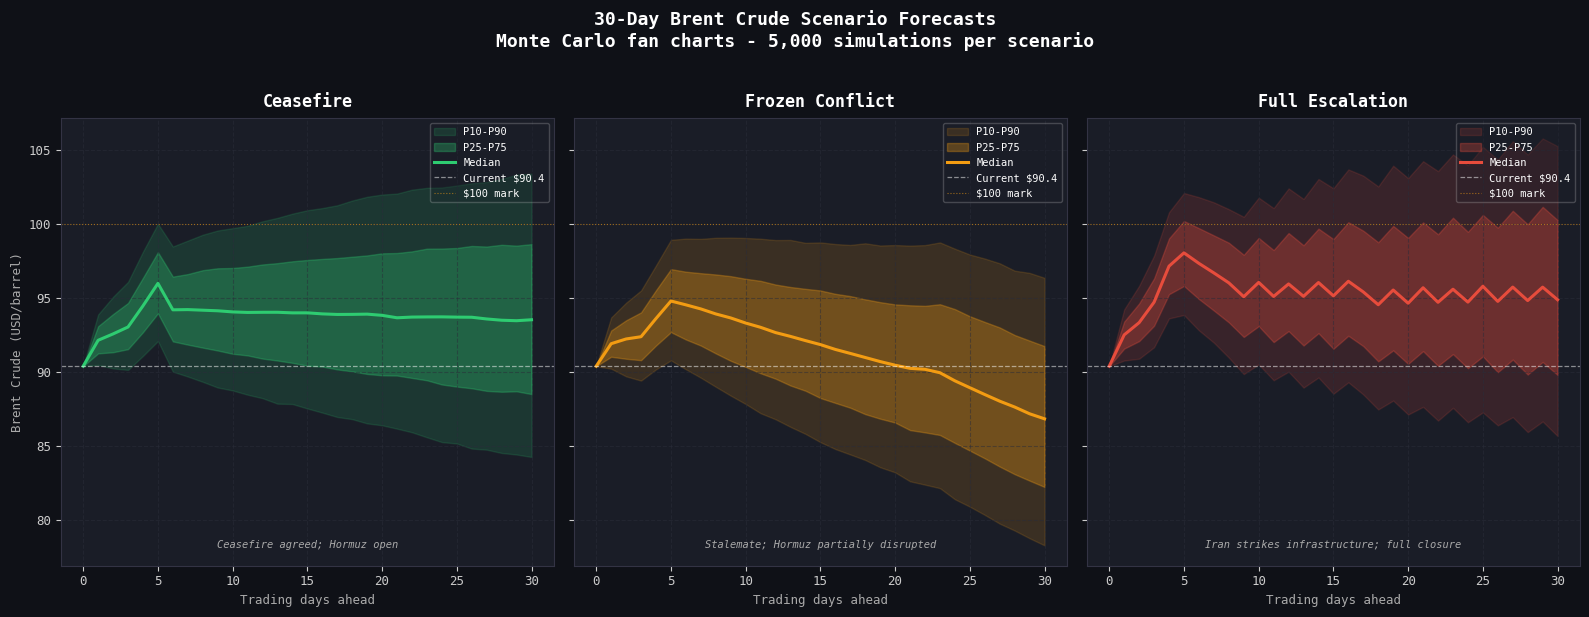

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True)
forecast_days = np.arange(0, HORIZON + 1)
summary_rows  = []

for ax, (name, paths) in zip(axes, scenario_results.items()):
    sp    = SCENARIOS[name]
    color = sp["color"]
    ax.set_facecolor("#1a1d27")
    ax.tick_params(colors="#cccccc", labelsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor("#333344")

    p10 = np.percentile(paths, 10, axis=0)
    p25 = np.percentile(paths, 25, axis=0)
    p50 = np.percentile(paths, 50, axis=0)
    p75 = np.percentile(paths, 75, axis=0)
    p90 = np.percentile(paths, 90, axis=0)

    ax.fill_between(forecast_days, p10, p90, alpha=0.15, color=color, label="P10-P90")
    ax.fill_between(forecast_days, p25, p75, alpha=0.30, color=color, label="P25-P75")
    ax.plot(forecast_days, p50, color=color, linewidth=2.2, label="Median")
    ax.axhline(last_close, color="white", linestyle="--",
               linewidth=0.9, alpha=0.5, label=f"Current ${last_close:.1f}")
    ax.axhline(100, color="#f39c12", linestyle=":",
               linewidth=0.8, alpha=0.6, label="$100 mark")

    ax.set_title(name, color="white", fontsize=12, fontweight="bold", pad=8)
    ax.set_xlabel("Trading days ahead", color="#aaaaaa", fontsize=9)
    ax.text(0.5, 0.04, sp["description"], transform=ax.transAxes,
            color="#aaaaaa", fontsize=7.5, ha="center", style="italic")
    ax.legend(fontsize=7.5, framealpha=0.25, labelcolor="white", loc="upper right")
    ax.grid(True)

    if ax == axes[0]:
        ax.set_ylabel("Brent Crude (USD/barrel)", color="#aaaaaa", fontsize=9)

    final = paths[:, -1]
    summary_rows.append({
        "scenario":        name,
        "current_price":   round(last_close, 2),
        "median_30d":      round(np.median(final), 2),
        "p10_30d":         round(np.percentile(final, 10), 2),
        "p90_30d":         round(np.percentile(final, 90), 2),
        "prob_above_100":  round((final > 100).mean() * 100, 1),
        "prob_above_120":  round((final > 120).mean() * 100, 1),
        "prob_below_80":   round((final < 80).mean() * 100, 1),
    })

fig.suptitle(
    "30-Day Brent Crude Scenario Forecasts\nMonte Carlo fan charts - 5,000 simulations per scenario",
    color="white", fontsize=13, fontweight="bold", y=1.02,
)
fig.patch.set_facecolor("#0f1117")
plt.tight_layout()
plt.savefig("../outputs/02_scenario_forecasts.png", dpi=150,
            bbox_inches="tight", facecolor="#0f1117")
plt.show()

In [12]:
summary = pd.DataFrame(summary_rows)
summary.to_csv("../outputs/02_scenario_summary.csv", index=False)
print("Saved to outputs/02_scenario_summary.csv\n")
summary

Saved to outputs/02_scenario_summary.csv



,scenario,current_price,median_30d,p10_30d,p90_30d,prob_above_100,prob_above_120,prob_below_80
0,Ceasefire,90.38,93.52,84.24,103.40,19.6,0.1,2.6
1,Frozen Conflict,90.38,86.82,78.26,96.35,4.1,0.0,15.5
2,Full Escalation,90.38,94.87,85.65,105.26,26.1,0.2,1.8
